In [1]:
import pandas as pd
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'

df = pd.read_csv(url)
 # Check for missing values in 'Age' and 'Fare' column
print(f"Expected values: {len(df['Age'])}, missing values: {df['Age'].isnull().sum()}")
print(f"Expected values: {len(df['Fare'])}, missing values: {df['Fare'].isnull().sum()}")

df['Age'] = df['Age'].fillna(df['Age'].median())

# Distribution check

for col in ['Age','Fare']:
    mean, median,  = df[col].mean(), df[col].median()
    skew = "right skewed" if mean > median * 1.1 else "left skewed" if mean * 1.1 < median else "symmetrical"
    print(f"{col} is {skew} (mean: {mean:.2f}, median: {median:.2f})")

Expected values: 891, missing values: 177
Expected values: 891, missing values: 0
Age is symmetrical (mean: 29.36, median: 28.00)
Fare is right skewed (mean: 32.20, median: 14.45)


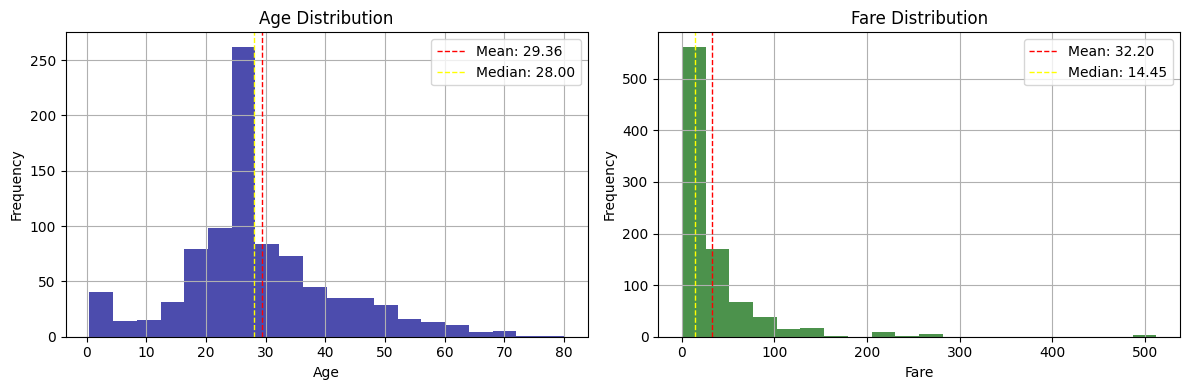

In [2]:
# Plot distribution for Age and Fare

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['Age'].hist(bins=20, color='darkblue', ax=axes[0], alpha=0.7)
axes[0].axvline(df['Age'].mean(), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {df["Age"].mean():.2f}')
axes[0].axvline(df['Age'].median(), color='yellow', linestyle='dashed', linewidth=1, label=f'Median: {df["Age"].median():.2f}')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')
axes[0].legend()

df['Fare'].hist(bins=20, color='darkgreen', ax=axes[1], alpha=0.7)
axes[1].axvline(df['Fare'].mean(), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {df["Fare"].mean():.2f}')
axes[1].axvline(df['Fare'].median(), color='yellow', linestyle='dashed', linewidth=1, label=f'Median: {df["Fare"].median():.2f}')
axes[1].set_title('Fare Distribution')
axes[1].set_xlabel('Fare')
axes[1].set_ylabel('Frequency')
axes[1].legend()


plt.tight_layout()
plt.savefig('week5_age_fare_distribution.png')

plt.show()


In [3]:
# Standard deviation check
fare_std = df['Fare'].std()
age_std = df['Age'].std()
print(f"Mean , Standard deviation (Fare):{df['Fare'].mean():.2f}, {fare_std:.2f}")
print(f"Mean , Standard deviation (Age): {df['Age'].mean():.2f}, {age_std:.3f}")

Mean , Standard deviation (Fare):32.20, 49.69
Mean , Standard deviation (Age): 29.36, 13.020


In [4]:
# Use log transformation to reduce skewness in Fare
import numpy as np

df['Fare_log'] = df['Fare'].apply(lambda x: np.log(x + 1))  # Add 1 to avoid log(0)
# Check distribution after log transformation
mean_log, median_log = df['Fare_log'].mean(), df['Fare_log'].median()
print(f"Fare_log is {'right skewed' if mean_log > median_log * 1.1 else 'left skewed' if mean_log * 1.1 < median_log else 'symmetrical'} (mean: {mean_log:.2f}, median: {median_log:.2f})")

#check standard deviation after log transformation
fare_log_std = df['Fare_log'].std()
print(f"Mean , Standard deviation (Fare_log):{df['Fare_log'].mean():.2f}, {fare_log_std:.2f}")

Fare_log is symmetrical (mean: 2.96, median: 2.74)
Mean , Standard deviation (Fare_log):2.96, 0.97


In [5]:
# Check correlation between all features
df['Sex_encoded'] = df['Sex'].map({'male':0,'female':1})
print(df.columns)
cols = ['Pclass', 'Sex_encoded', 'Age', 'Fare', 'Survived', 'SibSp', 'Parch', 'Fare_log']
correlation = df[cols].corr().round(2)
print(correlation)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Fare_log',
       'Sex_encoded'],
      dtype='str')
             Pclass  Sex_encoded   Age  Fare  Survived  SibSp  Parch  Fare_log
Pclass         1.00        -0.13 -0.34 -0.55     -0.34   0.08   0.02     -0.66
Sex_encoded   -0.13         1.00 -0.08  0.18      0.54   0.11   0.25      0.26
Age           -0.34        -0.08  1.00  0.10     -0.06  -0.23  -0.17      0.11
Fare          -0.55         0.18  0.10  1.00      0.26   0.16   0.22      0.79
Survived      -0.34         0.54 -0.06  0.26      1.00  -0.04   0.08      0.33
SibSp          0.08         0.11 -0.23  0.16     -0.04   1.00   0.41      0.32
Parch          0.02         0.25 -0.17  0.22      0.08   0.41   1.00      0.33
Fare_log      -0.66         0.26  0.11  0.79      0.33   0.32   0.33      1.00


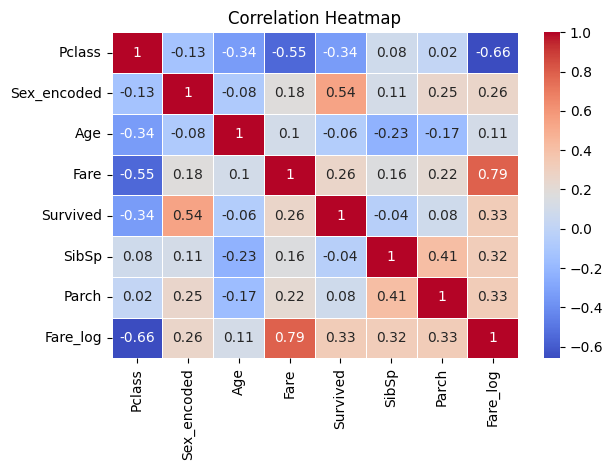

In [6]:
# Draw a heatmap of the correlation matrix
import seaborn as sns

sns.heatmap(correlation,annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('week5_correlation_heatmap.png')
plt.show()

In [7]:
# Bayes theorem 

# P(Survived|Female) = P(Female|Survived) * P(Survived) / P(Female)

total = len(df)
survived = df['Survived'].sum()
females = (df['Sex'] == 'female').sum()
females_survived = ((df['Sex'] == 'female') & (df['Survived'] == 1)).sum()
p_female = females / total
p_survived = survived / total
p_female_given_survived = females_survived / survived
p_survied_given_feamle = (p_female_given_survived * p_survived) / p_female

print(f"P(Female) = {p_female:.4f}")
print(f"P(Survived) = {p_survived:.4f}")
print(f"P(Female|Survived) = {p_female_given_survived:.4f}")
print(f"P(Survived|Female) = {p_survied_given_feamle:.4f}")
print(f"Actual P(Survived|Female) = {df[df['Sex']== 'female']['Survived'].mean():.4f}")

P(Female) = 0.3524
P(Survived) = 0.3838
P(Female|Survived) = 0.6813
P(Survived|Female) = 0.7420
Actual P(Survived|Female) = 0.7420
